# Rainfall regimes and seasonal rainfall domains of Ethiopia — JJAS, FMAM and ONDJ

**A training notebook: from the CHIRPS daily climatology to objective rainfall regimes and the operational
rainfall domain of each season**

This notebook reproduces, step by step, the regime-and-masking logic described in the
[scientific masking walkthrough](https://github.com/YonSci/-Operational-Multi-Model-Seasonal-Forecasting-System/blob/main/docs/scientific_masking/WALKTHROUGH.md) of the *Operational Multi-Model Seasonal Forecasting System*,
and applies it to three seasons:

| Season | Local name | Rainfall domain (walkthrough logic) |
| --- | --- | --- |
| **JJAS** (Jun–Sep) | Kiremt, main rains | Regime 1 + Regime 2, JJAS ≥ 120 mm and ≥ 20 % of annual rainfall |
| **FMAM** (Feb–May) | Belg, early rains | Regime 2 only, FMAM ≥ 80 mm |
| **ONDJ** (Oct–Jan) | Deyr / Hagaya, short rains | Regime 3 only, seasonal rainfall ≥ 30 mm |

> **Season name.** The request named "ONJF"; this notebook uses **ONDJ** (October–January), the season of the
> project's September-initialized forecast. The walkthrough defines the Deyr domain on OND (≥ 30 mm); here the same
> rule is applied to ONDJ. To use another window, change `SEASONS` in section 7.

> **Scope.** The four climate regimes are defined and validated **for Ethiopia only** (walkthrough, "Important
> Regional Scope").

**Learning objectives.**
1. Compute a daily rainfall climatology and its Fourier harmonics (Dunning et al., 2016).
2. Use the harmonic ratio and peak timing to classify the four Ethiopian rainfall regimes.
3. Build a season's rainfall domain from the regimes and seasonal rainfall thresholds.
4. Check the result against reference stations and the project's existing JJAS mask.

## Table of contents

1. [Setup](#s1)
2. [Data: the CHIRPS daily climatology](#s2)
3. [Harmonic analysis (Dunning et al., 2016)](#s3)
4. [Peak timing (EMI refinement)](#s4)
5. [The four rainfall regimes](#s5)
6. [Check against 20 reference stations](#s6)
7. [From regimes to seasonal rainfall domains](#s7)
8. [JJAS — Kiremt domain](#s8)
9. [FMAM — Belg domain](#s9)
10. [ONDJ — Deyr / short-rains domain](#s10)
11. [The three domains together](#s11)
12. [Saving the masks](#s12)
13. [Exporting shapefiles and GeoJSON](#s13)
14. [Caveats](#s14)
15. [Exercises](#s15)
16. [References](#s16)

<a id="s1"></a>
## 1. Setup

The classification uses the project's port of the walkthrough code, `scripts/github_regime_core.py`
(`classify()`), pinned to the source commit and with two documented corrections: the 365-day cycle aligns calendar
days correctly (29 February excluded), and cells with missing observations are never assigned a regime.

In [1]:
import os, sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT / 'scripts'))

import numpy as np, pandas as pd, xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, BoundaryNorm
from matplotlib.patches import Patch
from IPython.display import display, Markdown
from github_regime_core import classify, remove_small, LABELS, METHOD, SOURCE_URL, MONTH_EDGES
pd.set_option('display.precision', 2)

# Palette (validated): regimes R1 blue, R2 aqua, R3 orange; R0 arid in neutral slate.
SURFACE, INK, INK2, GRID, LAND = '#fcfcfb', '#0b0b0b', '#52514e', '#e4e3df', '#ecebe7'
BLUE, AQUA, ORANGE, SLATE = '#2a78d6', '#1baf7a', '#eb6834', '#8a8986'
REGIME_COLORS = {0: SLATE, 1: BLUE, 2: AQUA, 3: ORANGE}
REGIME_NAMES = {0: 'R0 Arid / marginal', 1: 'R1 Western unimodal', 2: 'R2 Bimodal type-1 highlands',
                3: 'R3 Bimodal type-2 lowlands'}
SEQ = LinearSegmentedColormap.from_list('seq', ['#cde2fb', '#86b6ef', '#3987e5', '#256abf', '#184f95', '#0d366b'])
plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
                     'text.color': INK, 'axes.labelcolor': INK2, 'xtick.color': INK2, 'ytick.color': INK2,
                     'axes.edgecolor': GRID, 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': .6,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10,
                     'axes.titlesize': 11, 'axes.titleweight': 'bold', 'figure.dpi': 110})
MONTHS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
print('Classification method:', METHOD); print('Source:', SOURCE_URL)

Classification method: github_refined_corrected_calendar_v1
Source: https://github.com/YonSci/-Operational-Multi-Model-Seasonal-Forecasting-System/blob/07879e42290dd5efd1d75f137961378ca7e39ea2/scripts/compute_seasonal_masks.py


In [2]:
def map_axes(ax, title):
    ax.set_title(title, loc='left'); ax.set_aspect('equal'); ax.grid(False)
    ax.set_xlabel('Longitude (°E)'); ax.set_ylabel('Latitude (°N)')
    ax.contour(lon, lat, country, levels=[.5], colors=[INK2], linewidths=.8)

def area_share(mask):
    # Share of Ethiopia's area (cos-latitude weights) and the cell count.
    return float(100 * W[mask & country].sum() / W[country].sum()), int((mask & country).sum())

<a id="s2"></a>
## 2. Data: the CHIRPS daily climatology

**Stage 1 of the walkthrough.** CHIRPS v2.0 daily rainfall on the 0.25° grid, 1993–2025 (the calibration window that
matches the ECMWF SEAS5 hindcasts), is averaged into a **365-day climatology** `Q(d)` for every grid cell. The file was
prepared by `scripts/prepare_regimes.py`; 29 February is excluded from the daily cycle.

Years: 1993 - 2025 | grid (48, 60) | Ethiopia cells 1484
Calendar policy: 365-day cycle excludes Feb29 by month-day; actual monthly totals retain Feb29; complete calendar required


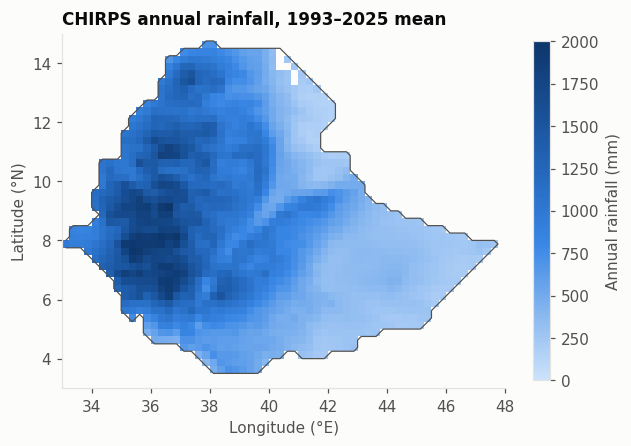

In [3]:
clim = xr.open_dataset('data/processed/regime_climatology/descriptive_1993_2025.nc')
lat, lon = clim.lat.values.astype(float), clim.lon.values.astype(float)
Q = clim.daily_climatology.transpose('day', 'lat', 'lon').values          # mm/day, 365 x lat x lon
country = clim.region_mask.values == 1
W = np.cos(np.deg2rad(lat))[:, None] * np.ones(len(lon))
print('Years:', json.loads(clim.attrs['training_years'])[0], '-', json.loads(clim.attrs['training_years'])[-1],
      '| grid', Q.shape[1:], '| Ethiopia cells', int(country.sum()))
print('Calendar policy:', clim.attrs['calendar_policy'])
annual = Q.sum(axis=0)
fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.pcolormesh(lon, lat, np.where(country, annual, np.nan), cmap=SEQ, vmin=0, vmax=2000, shading='auto')
fig.colorbar(im, ax=ax, shrink=.8, label='Annual rainfall (mm)'); map_axes(ax, 'CHIRPS annual rainfall, 1993–2025 mean')
plt.show()

<a id="s3"></a>
## 3. Harmonic analysis (Dunning et al., 2016)

**Stage 2 of the walkthrough.** The annual cycle is decomposed into Fourier harmonics:

$$Q(d) = \bar{Q} + \sum_k C_k \cos\left(\frac{2\pi k d}{365} - \phi_k\right)$$

* $C_1$ — amplitude of the **annual** harmonic (one wet season per year);
* $C_2$ — amplitude of the **semi-annual** harmonic (two wet seasons per year);
* **harmonic ratio** $r_H = C_2 / C_1$: below 1 the annual cycle dominates (unimodal), at or above 1 the
  semi-annual cycle dominates (bimodal).

The figure shows the climatology and its first two harmonics at three contrasting places.

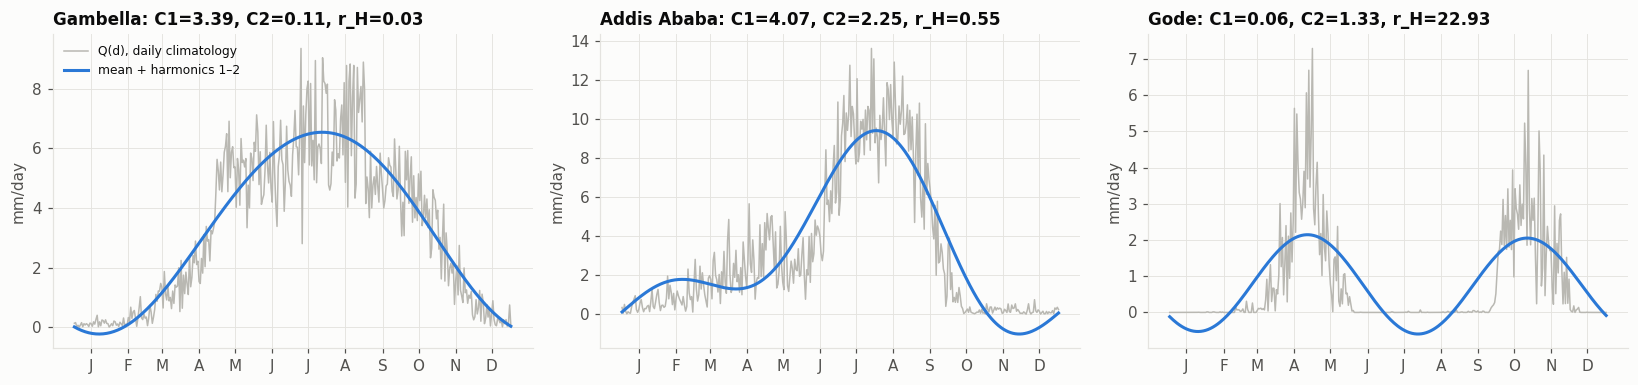

In [4]:
theta = 2 * np.pi * (np.arange(1, 366) - .5) / 365
def harmonics(q):
    a = [2 / 365 * np.cos(k * theta) @ q for k in (1, 2)]
    b = [2 / 365 * np.sin(k * theta) @ q for k in (1, 2)]
    fit = q.mean() + sum(a[i] * np.cos((i + 1) * theta) + b[i] * np.sin((i + 1) * theta) for i in range(2))
    return np.hypot(a[0], b[0]), np.hypot(a[1], b[1]), fit

def cell(la, lo):
    # Nearest valid Ethiopian grid cell.
    d = (lat[:, None] - la) ** 2 + (lon[None, :] - lo) ** 2
    d[~(country & np.isfinite(Q).all(axis=0))] = np.inf
    return np.unravel_index(np.argmin(d), d.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=False)
for ax, (name, la, lo) in zip(axes, [('Gambella', 8.25, 34.58), ('Addis Ababa', 9.03, 38.74), ('Gode', 5.90, 43.58)]):
    i, j = cell(la, lo); q = Q[:, i, j]; c1, c2, fit = harmonics(q)
    ax.plot(np.arange(1, 366), q, color='#b9b8b2', lw=1, label='Q(d), daily climatology')
    ax.plot(np.arange(1, 366), fit, color=BLUE, lw=2, label='mean + harmonics 1–2')
    ax.set_title(f'{name}: C1={c1:.2f}, C2={c2:.2f}, r_H={c2 / c1:.2f}', loc='left')
    ax.set_xticks(MONTH_EDGES[:-1] + 15, [m[0] for m in MONTHS]); ax.set_ylabel('mm/day')
axes[0].legend(frameon=False, fontsize=8, loc='upper left'); plt.tight_layout(); plt.show()

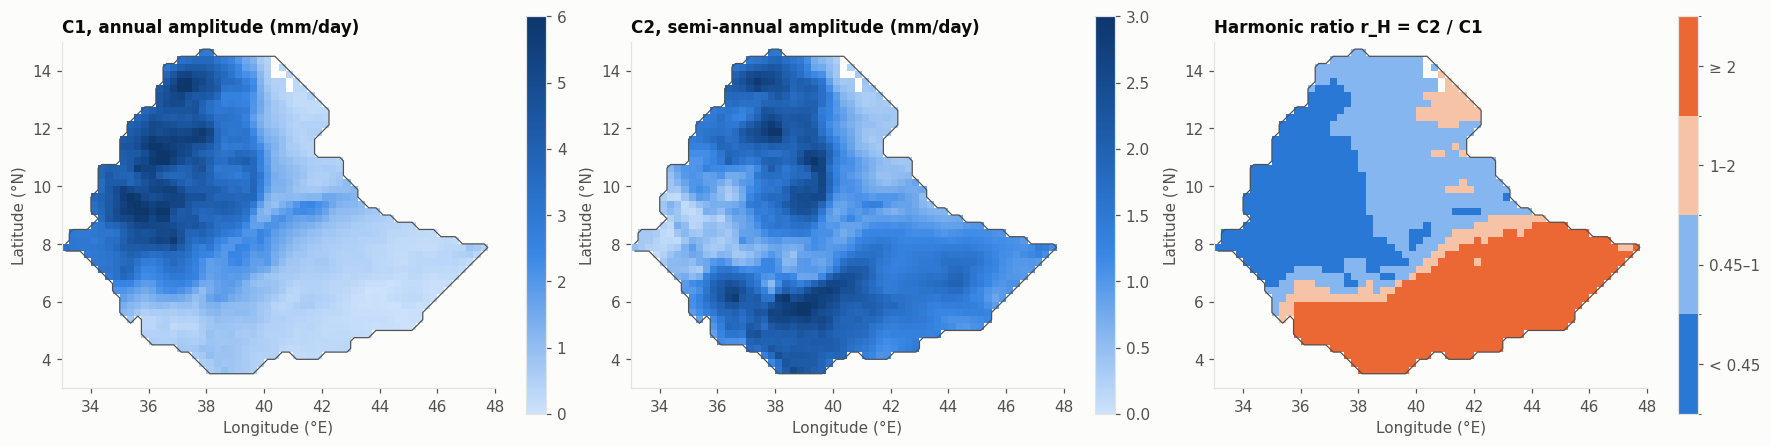

In [5]:
fields = classify(Q, lat, lon, country)          # the walkthrough classification (all stages)
shape = (len(lat), len(lon)); F = {k: np.asarray(v).reshape(shape) for k, v in fields.items()}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), layout='constrained')
for ax, key, title, vmax in [(axes[0], 'C1', 'C1, annual amplitude (mm/day)', 6),
                             (axes[1], 'C2', 'C2, semi-annual amplitude (mm/day)', 3)]:
    im = ax.pcolormesh(lon, lat, np.where(country, F[key], np.nan), cmap=SEQ, vmin=0, vmax=vmax, shading='auto')
    fig.colorbar(im, ax=ax, shrink=.8); map_axes(ax, title)
ratio = np.where(country, F['harmonic_ratio'], np.nan)
cmap = ListedColormap([BLUE, '#86b6ef', '#f6c3a6', ORANGE]); norm = BoundaryNorm([0, .45, 1, 2, 50], 4)
im = axes[2].pcolormesh(lon, lat, ratio, cmap=cmap, norm=norm, shading='auto')
cb = fig.colorbar(im, ax=axes[2], shrink=.8, ticks=[.225, .725, 1.5, 26]); cb.ax.set_yticklabels(['< 0.45', '0.45–1', '1–2', '≥ 2'])
map_axes(axes[2], 'Harmonic ratio r_H = C2 / C1'); plt.show()

**Why the ratio alone is not enough.** In the central and northern highlands the summer Kiremt rains are so much larger
than the spring Belg rains that $C_1$ dominates and $r_H$ stays around 0.4–0.85, even though these places have **two**
rainy seasons. The walkthrough therefore adds peak-timing rules (next section).

<a id="s4"></a>
## 4. Peak timing (EMI refinement)

**Stage 3 of the walkthrough.** Monthly climatological totals are lightly smoothed (weights ¼, ½, ¼ across adjacent
months) and the local maxima are found. The **primary peak** is the wettest month; the **secondary peak** is the
second-highest local maximum. Peaks in **March–May** indicate Belg / Gu rains; peaks in **October–November** indicate
Deyr / Hagaya rains.

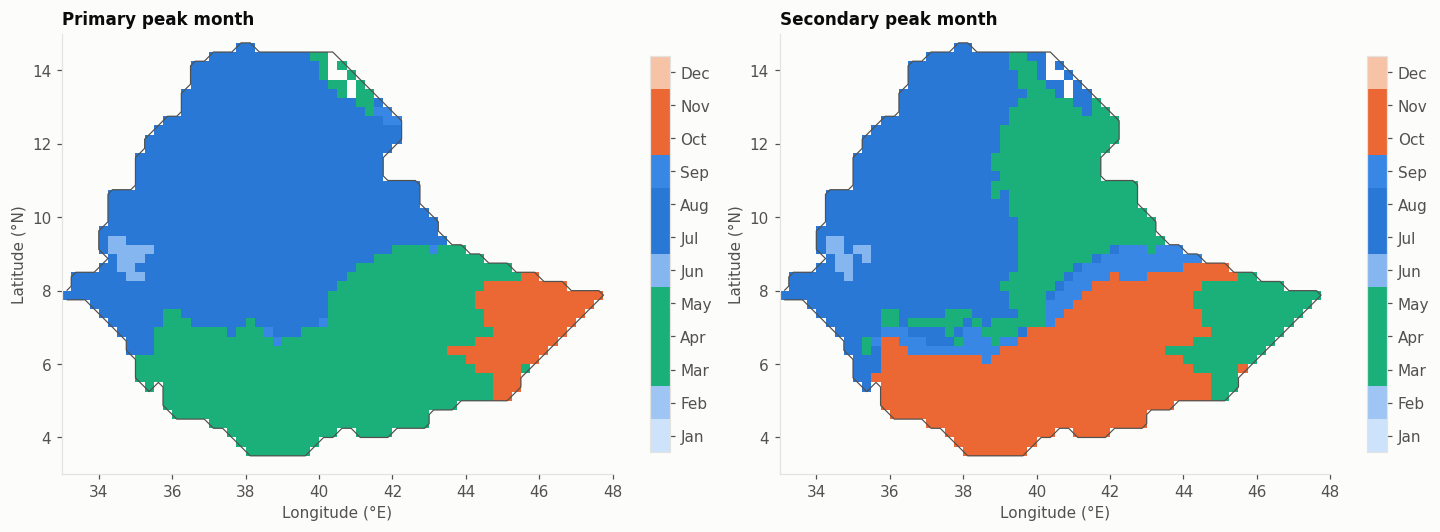

Spring (Mar-May) peaks shown in aqua, summer (Jul-Aug) in blue, Oct-Nov in orange.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), layout='constrained')
peak_cmap = ListedColormap(['#cde2fb', '#9ec5f4', AQUA, AQUA, AQUA, '#86b6ef', BLUE, BLUE, '#3987e5', ORANGE, ORANGE, '#f6c3a6'])
for ax, key, title in [(axes[0], 'monthly_peak1', 'Primary peak month'), (axes[1], 'monthly_peak2', 'Secondary peak month')]:
    z = np.where(country & (F[key] > 0), F[key], np.nan)
    im = ax.pcolormesh(lon, lat, z, cmap=peak_cmap, vmin=.5, vmax=12.5, shading='auto')
    cb = fig.colorbar(im, ax=ax, shrink=.8, ticks=range(1, 13)); cb.ax.set_yticklabels(MONTHS); map_axes(ax, title)
plt.show()
print('Spring (Mar-May) peaks shown in aqua, summer (Jul-Aug) in blue, Oct-Nov in orange.')

<a id="s5"></a>
## 5. The four rainfall regimes

`classify()` applies the walkthrough's rules in a fixed priority. Seasonal totals use the 365-day climatology
(FMAM = Feb–May, JJAS = Jun–Sep, OND = Oct–Dec, JJA = Jun–Aug); a share is the season's fraction of annual rainfall.

| Regime | Rule (all must hold) |
| --- | --- |
| **R0 Arid / marginal** | annual < 200 mm, or annual < 300 mm with OND < 30 mm |
| **R3 Bimodal type-2 lowlands** (Gu–Deyr) | OND ≥ 30 mm, OND share ≥ 8 %, JJA < 1.3 × OND, and (r_H ≥ 0.70 or a peak in Oct/Nov) |
| **R2 Bimodal type-1 highlands** (Belg–Kiremt) | FMAM ≥ 50 mm, FMAM share ≥ 10 %, JJAS ≥ 120 mm, JJAS share ≥ 25 %, east of 38°E (or 37.5°E north of 10°N), and (r_H ≥ 0.38 or a secondary peak in Mar–May) |
| **R1 Western unimodal** | every remaining valid Ethiopian cell |

Priority: R0 first, then R3, then R2; R1 is the residual. Finally, isolated patches smaller than the minimum size
(2 cells for R0, 3 for R2 and R3) are merged into R1 (4-connected cleanup).

,cells,area_pct,walkthrough_cells,walkthrough_pct
regime,,,,
R0 Arid / marginal,64,4.27,65,4.4
R1 Western unimodal,421,28.30,426,28.7
R2 Bimodal type-1 highlands,418,28.04,416,28.0
R3 Bimodal type-2 lowlands,575,39.00,578,38.9


Cells with missing observations (no regime): 6


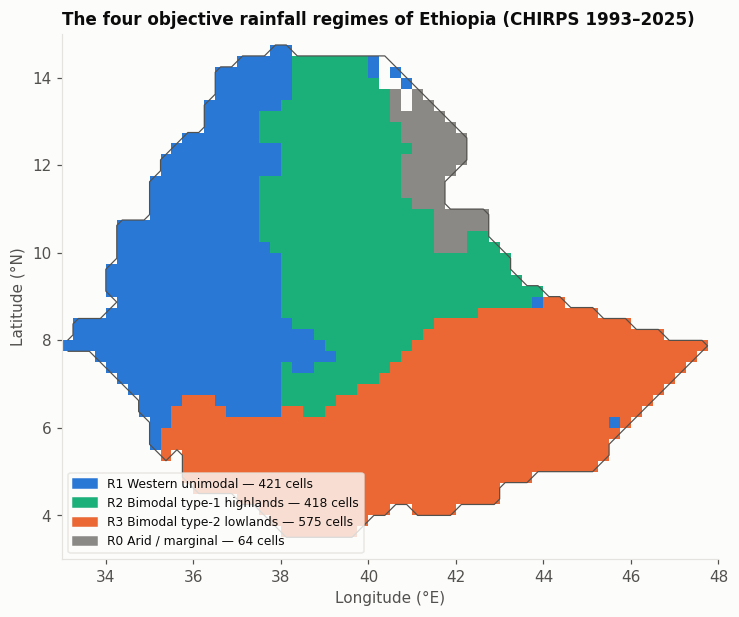

Identical to the project's stored regime map (evidence/…masks.nc): True


In [7]:
regime = F['regime_cleaned']
rows = []
walk = {0: (65, 4.4), 1: (426, 28.7), 2: (416, 28.0), 3: (578, 38.9)}
for g in range(4):
    pct, n = area_share(regime == g)
    rows.append(dict(regime=REGIME_NAMES[g], cells=n, area_pct=pct, walkthrough_cells=walk[g][0], walkthrough_pct=walk[g][1]))
display(pd.DataFrame(rows).set_index('regime'))
print('Cells with missing observations (no regime):', int((regime == -1).sum()))

fig, ax = plt.subplots(figsize=(8, 6.2))
z = np.where(country & (regime >= 0), regime, np.nan)
ax.pcolormesh(lon, lat, z, cmap=ListedColormap([REGIME_COLORS[g] for g in range(4)]), vmin=-.5, vmax=3.5, shading='auto')
map_axes(ax, 'The four objective rainfall regimes of Ethiopia (CHIRPS 1993–2025)')
ax.legend(handles=[Patch(color=REGIME_COLORS[g], label=f'{REGIME_NAMES[g]} — {rows[g]["cells"]} cells') for g in [1, 2, 3, 0]],
          loc='lower left', fontsize=8, frameon=True, facecolor=SURFACE, edgecolor=GRID)
plt.show()
stored = xr.open_dataset('evidence/followup_regime_comparison_and_masks.nc').github_regime_cleaned.values
print('Identical to the project\'s stored regime map (evidence/…masks.nc):', np.array_equal(stored, regime))

The cell counts differ from the walkthrough's by a few cells per regime because of the two corrections in the port
(calendar alignment and missing-data handling); the spatial pattern is the same.

<a id="s6"></a>
## 6. Check against 20 reference stations

The walkthrough lists 20 stations with their verified climatological regime. The grid cell nearest to each station is
looked up in the regime map. Monthly climatology profiles are shown for eight of them.

In [8]:
stations = [('Gambella', 8.25, 34.58, 1), ('Assosa', 10.07, 34.53, 1), ('Jimma', 7.67, 36.83, 1), ('Bedele', 8.45, 36.35, 1),
            ('Gore', 8.15, 35.53, 1), ('Nekemte', 9.08, 36.55, 1), ('Addis Ababa', 9.03, 38.74, 2), ('Debre Markos', 10.33, 37.73, 2),
            ('Gondar', 12.60, 37.47, 2), ('Kombolcha', 11.08, 39.73, 2), ('Mekelle', 13.50, 39.47, 2), ('Hawassa', 7.05, 38.48, 2),
            ('Dire Dawa', 9.60, 41.87, 2), ('Harar', 9.31, 42.13, 2), ('Gode', 5.90, 43.58, 3), ('Kibre Dehar', 6.73, 44.28, 3),
            ('Negelle Borana', 5.33, 39.58, 3), ('Moyale', 3.53, 39.05, 3), ('Jijiga', 9.35, 42.80, 3), ('Semera', 11.79, 41.01, 0)]
rows = []
for name, la, lo, ref in stations:
    i, j = cell(la, lo)
    rows.append(dict(station=name, lat=la, lon=lo, grid=f'{lat[i]:.3f}, {lon[j]:.3f}', annual_mm=annual[i, j],
                     r_H=F['harmonic_ratio'][i, j], peaks=f"{MONTHS[F['monthly_peak1'][i, j] - 1]}/{MONTHS[F['monthly_peak2'][i, j] - 1]}",
                     walkthrough=f'R{ref}', this_notebook=f'R{regime[i, j]}', agree=regime[i, j] == ref))
check = pd.DataFrame(rows)
display(check.style.format({'annual_mm': '{:.0f}', 'r_H': '{:.2f}'}).hide(axis='index'))
print(f'Agreement: {check.agree.sum()}/{len(check)} stations')
print('Disagreements:'); display(check[~check.agree][['station', 'grid', 'annual_mm', 'r_H', 'peaks', 'walkthrough', 'this_notebook']])

station,lat,lon,grid,annual_mm,r_H,peaks,walkthrough,this_notebook,agree
Gambella,8.250000,34.580000,"8.125, 34.625",1189,0.03,Jul/Jul,R1,R1,True
Assosa,10.070000,34.530000,"10.125, 34.625",1197,0.14,Jul/Jul,R1,R1,True
Jimma,7.670000,36.830000,"7.625, 36.875",1599,0.10,Jul/Jul,R1,R1,True
Bedele,8.450000,36.350000,"8.375, 36.375",1811,0.07,Jul/Jul,R1,R1,True
Gore,8.150000,35.530000,"8.125, 35.625",1930,0.10,Aug/Aug,R1,R1,True
Nekemte,9.080000,36.550000,"9.125, 36.625",2000,0.15,Jul/Jul,R1,R1,True
Addis Ababa,9.030000,38.740000,"9.125, 38.625",1180,0.55,Aug/Aug,R2,R2,True
Debre Markos,10.330000,37.730000,"10.375, 37.625",1333,0.39,Aug/Aug,R2,R2,True
Gondar,12.600000,37.470000,"12.625, 37.375",1198,0.39,Jul/Jul,R2,R1,False
Kombolcha,11.080000,39.730000,"11.125, 39.625",1150,0.74,Aug/Apr,R2,R2,True


Agreement: 18/20 stations
Disagreements:


,station,grid,annual_mm,r_H,peaks,walkthrough,this_notebook
8,Gondar,"12.625, 37.375",1198.44,0.39,Jul/Jul,R2,R1
18,Jijiga,"9.375, 42.875",544.52,0.64,Aug/Apr,R3,R2


**Why two stations differ.** The comparison uses the 0.25° grid cell nearest to each station, not the station record.

* **Gondar** comes out as R1 (western unimodal): its grid cell (12.625°N, 37.375°E) has a single July peak and
  $r_H pprox 0.39$, and it lies just west of the highland geography rule (37.5°E north of 10°N), so it cannot be
  promoted to R2. The walkthrough lists the town as R2; the cell sits on the boundary between the two regimes.
* **Jijiga** comes out as R2 (type-1 highlands): its cell has an August primary and April secondary peak with little
  October–November rain, so the lowland (Deyr) rule does not hold. The walkthrough lists it as R3; it lies on the
  highland–lowland transition east of Harar.

Both are boundary cases where a 28 km cell and a point station can legitimately disagree.

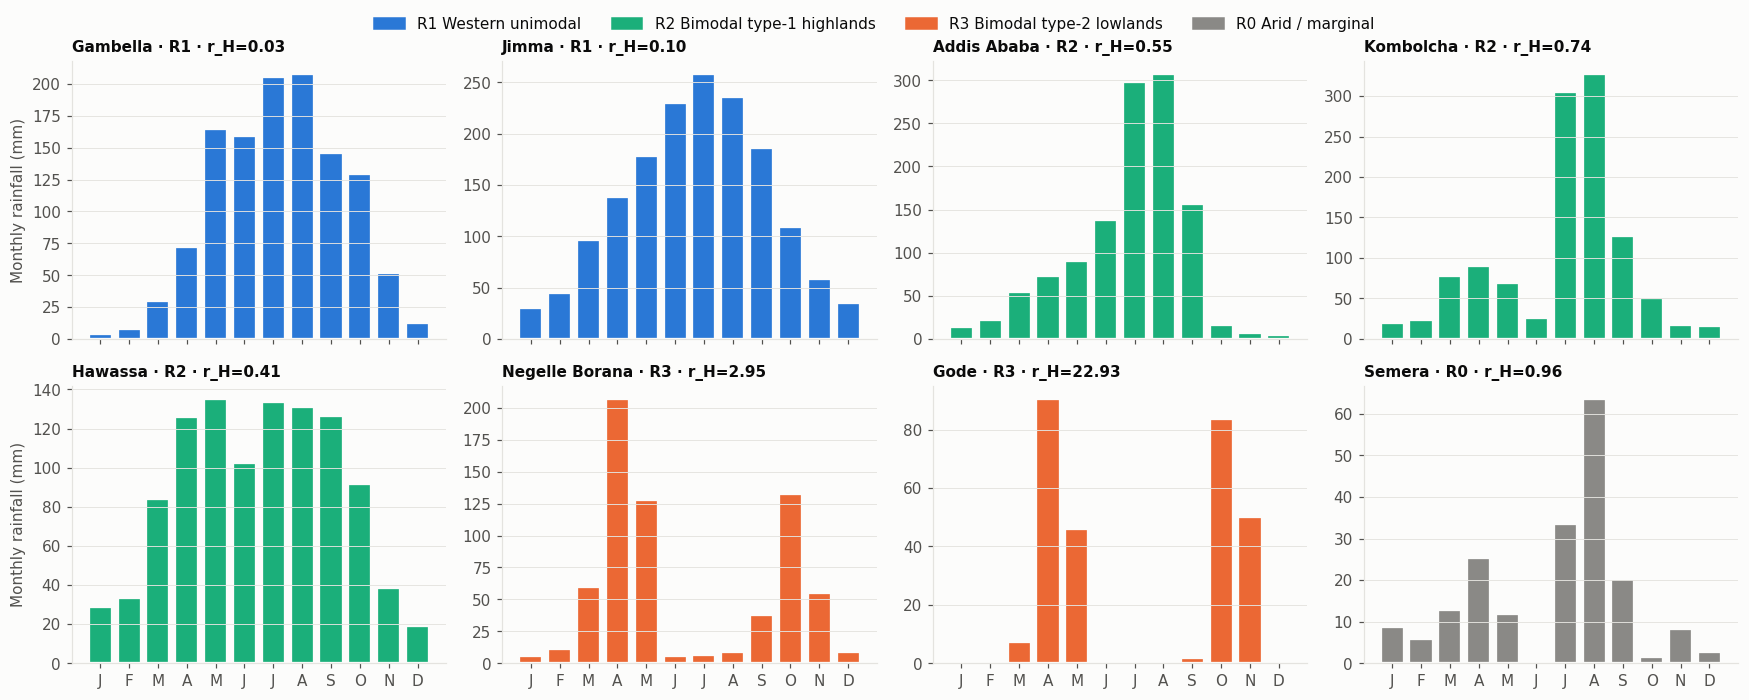

In [9]:
pick = ['Gambella', 'Jimma', 'Addis Ababa', 'Kombolcha', 'Hawassa', 'Negelle Borana', 'Gode', 'Semera']
fig, axes = plt.subplots(2, 4, figsize=(16, 6.2), sharex=True)
mon = np.stack([Q[a:b].sum(axis=0) for a, b in zip(MONTH_EDGES[:-1], MONTH_EDGES[1:])])
for ax, name in zip(axes.ravel(), pick):
    r = check.set_index('station').loc[name]; i, j = cell(r.lat, r.lon); g = regime[i, j]
    ax.bar(range(12), mon[:, i, j], color=REGIME_COLORS[g], edgecolor=SURFACE, linewidth=1.5)
    ax.set_title(f'{name} · R{g} · r_H={F["harmonic_ratio"][i, j]:.2f}', loc='left', fontsize=10)
    ax.set_xticks(range(12), [m[0] for m in MONTHS]); ax.grid(axis='x', visible=False)
for ax in axes[:, 0]: ax.set_ylabel('Monthly rainfall (mm)')
fig.legend(handles=[Patch(color=REGIME_COLORS[g], label=REGIME_NAMES[g]) for g in [1, 2, 3, 0]],
           loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(.5, 1.03))
plt.tight_layout(); plt.show()

<a id="s7"></a>
## 7. From regimes to seasonal rainfall domains

**Stage 4 of the walkthrough.** A season's operational domain keeps only the regimes for which that season is a real
rainy season, and requires enough climatological rainfall in the season. This avoids showing outlooks (or detecting
onsets) where no physical rainy season exists — for example JJAS in the southern pastoral lowlands, or Belg in the
western unimodal zone where March–May rain is simply the start of the long summer season.

| Season | Regimes | Rainfall rule | Walkthrough reference |
| --- | --- | --- | --- |
| JJAS | R1 + R2 | JJAS ≥ 120 mm and JJAS ≥ 20 % of annual | Kiremt domain, 832 cells (56.0 %) |
| FMAM | R2 | FMAM ≥ 80 mm | Belg domain, 416 cells (28.0 %) |
| ONDJ | R3 | ONDJ ≥ 30 mm | Deyr domain (OND ≥ 30 mm), 578 cells (38.9 %) |

As in the project's existing JJAS mask, patches smaller than 3 cells are removed (4-connected). The walkthrough's onset
detection-rate filter (DR ≥ 60 %) is **not** applied: it needs onset/cessation diagnostics, which are not part of this
rainfall-total project.

In [10]:
def season_total(months):
    # Climatological total for a list of calendar months (1-12), from the 365-day cycle.
    return sum(Q[MONTH_EDGES[m - 1]:MONTH_EDGES[m]].sum(axis=0) for m in months)

SEASONS = {
    'JJAS': dict(months=[6, 7, 8, 9], regimes=[1, 2], min_mm=120, min_share=0.20, name='Kiremt (main rains)'),
    'FMAM': dict(months=[2, 3, 4, 5], regimes=[2], min_mm=80, min_share=None, name='Belg (early rains)'),
    'ONDJ': dict(months=[10, 11, 12, 1], regimes=[3], min_mm=30, min_share=None, name='Deyr / Hagaya (short rains)'),
}
domains, totals = {}, {}
for s, rule in SEASONS.items():
    tot = season_total(rule['months']); share = np.divide(tot, annual, out=np.zeros_like(tot), where=annual > 10)
    keep = np.isin(regime, rule['regimes']) & (tot >= rule['min_mm']) & country
    if rule['min_share'] is not None:
        keep &= share >= rule['min_share']
    domains[s] = remove_small(keep, 3); totals[s] = tot
summary = []
for s, rule in SEASONS.items():
    pct, n = area_share(domains[s])
    summary.append(dict(season=s, name=rule['name'], regimes='+'.join(f'R{g}' for g in rule['regimes']),
                        rule=f"≥ {rule['min_mm']} mm" + (f", ≥ {rule['min_share']:.0%} of annual" if rule['min_share'] else ''),
                        cells=n, area_pct=pct, median_season_mm=float(np.median(totals[s][domains[s]]))))
summary = pd.DataFrame(summary).set_index('season'); summary

,name,regimes,rule,cells,area_pct,median_season_mm
season,,,,,,
JJAS,Kiremt (main rains),R1+R2,"≥ 120 mm, ≥ 20% of annual",833,55.93,732.84
FMAM,Belg (early rains),R2,≥ 80 mm,418,28.04,193.58
ONDJ,Deyr / Hagaya (short rains),R3,≥ 30 mm,575,39.00,152.10


<a id="s8"></a>
## 8. JJAS — Kiremt domain

**Rule:** Regimes R1 + R2; JJAS ≥ 120 mm and ≥ 20 % of annual rainfall. Left: the season's climatological rainfall with the domain outlined. Right: the domain coloured
by the regime each cell belongs to.

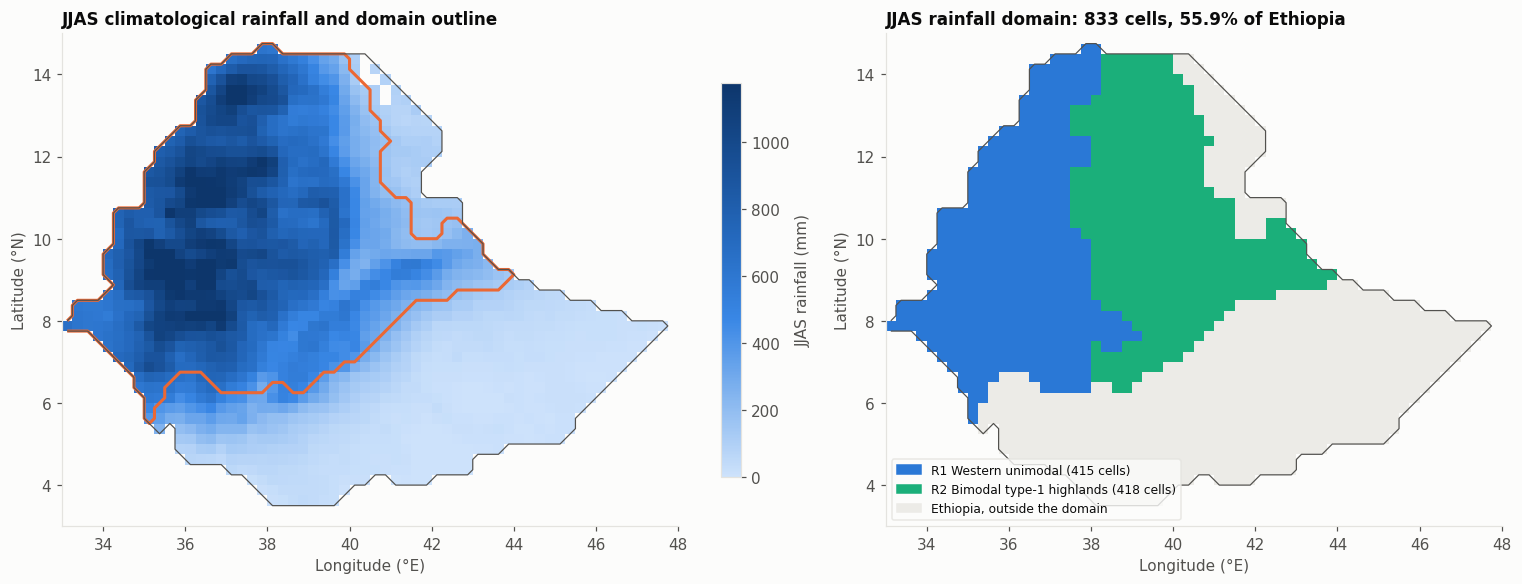

Excluded by the rainfall rule (right regime, too little rain): 6 cells


In [11]:
S = 'JJAS'; dom = domains[S]; tot = totals[S]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), layout='constrained')
im = axes[0].pcolormesh(lon, lat, np.where(country, tot, np.nan), cmap=SEQ, vmin=0,
                        vmax=float(np.nanpercentile(tot[country], 98)), shading='auto')
fig.colorbar(im, ax=axes[0], shrink=.8, label=f'{S} rainfall (mm)')
axes[0].contour(lon, lat, dom, levels=[.5], colors=[ORANGE if S != 'ONDJ' else INK], linewidths=2)
map_axes(axes[0], f'{S} climatological rainfall and domain outline')
z = np.where(dom, regime, np.nan)
axes[1].pcolormesh(lon, lat, np.where(country, 0, np.nan), cmap=ListedColormap([LAND]), shading='auto')
axes[1].pcolormesh(lon, lat, z, cmap=ListedColormap([REGIME_COLORS[g] for g in range(4)]), vmin=-.5, vmax=3.5, shading='auto')
pct, n = area_share(dom)
map_axes(axes[1], f'{S} rainfall domain: {n} cells, {pct:.1f}% of Ethiopia')
present = [g for g in range(4) if (dom & (regime == g)).any()]
axes[1].legend(handles=[Patch(color=REGIME_COLORS[g], label=f'{REGIME_NAMES[g]} ({int((dom & (regime == g)).sum())} cells)') for g in present]
               + [Patch(color=LAND, label='Ethiopia, outside the domain')], loc='lower left', fontsize=8,
               facecolor=SURFACE, edgecolor=GRID)
plt.show()
print('Excluded by the rainfall rule (right regime, too little rain):',
      int((np.isin(regime, SEASONS[S]['regimes']) & country & ~dom).sum()), 'cells')

**Check against the project's existing mask.** The JJAS domain should be identical to the R1+R2 rainfall domain used
on the results site (`evidence/followup_regime_comparison_and_masks.nc`, variable `github_jjas_r12_rainfall_cleaned`).

In [12]:
stored_r12 = xr.open_dataset('evidence/followup_regime_comparison_and_masks.nc').github_jjas_r12_rainfall_cleaned.values == 1
print('Identical to the project\'s JJAS R1+R2 rainfall domain:', np.array_equal(stored_r12, domains['JJAS']),
      '| cells:', int(stored_r12.sum()), 'vs', int(domains['JJAS'].sum()))

Identical to the project's JJAS R1+R2 rainfall domain: True | cells: 833 vs 833


<a id="s9"></a>
## 9. FMAM — Belg domain

**Rule:** Regime R2 only; FMAM ≥ 80 mm. Left: the season's climatological rainfall with the domain outlined. Right: the domain coloured
by the regime each cell belongs to.

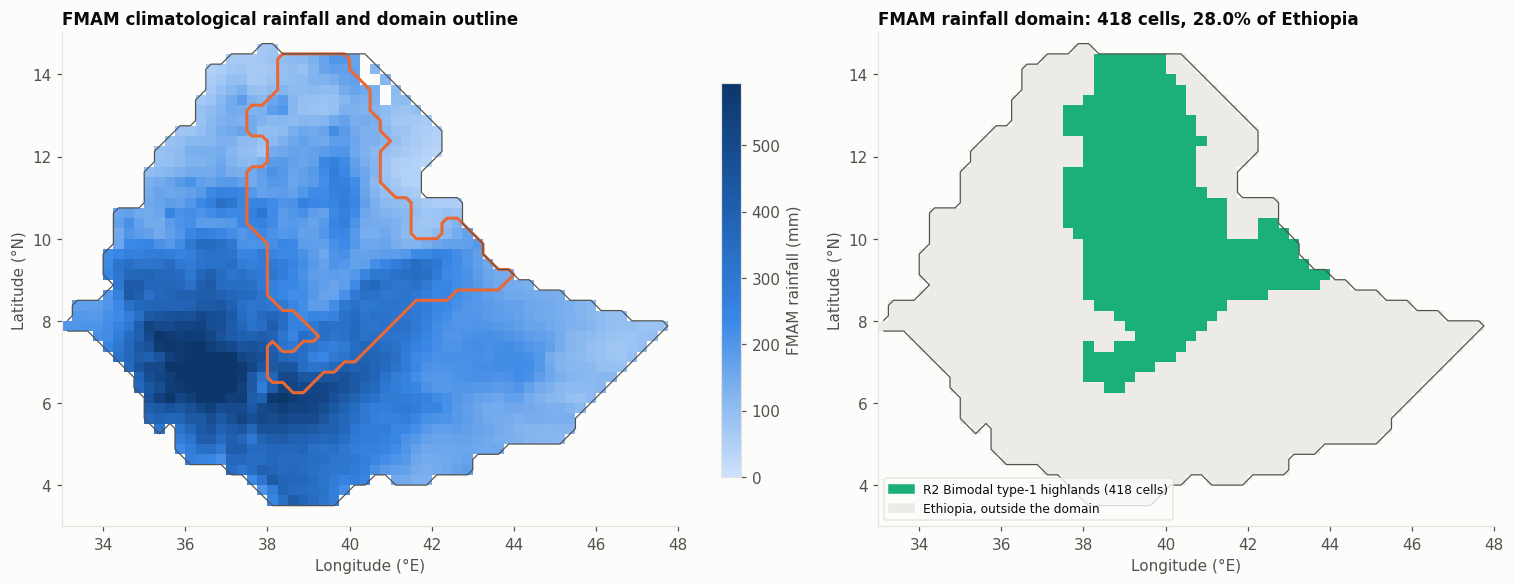

Excluded by the rainfall rule (right regime, too little rain): 0 cells


In [13]:
S = 'FMAM'; dom = domains[S]; tot = totals[S]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), layout='constrained')
im = axes[0].pcolormesh(lon, lat, np.where(country, tot, np.nan), cmap=SEQ, vmin=0,
                        vmax=float(np.nanpercentile(tot[country], 98)), shading='auto')
fig.colorbar(im, ax=axes[0], shrink=.8, label=f'{S} rainfall (mm)')
axes[0].contour(lon, lat, dom, levels=[.5], colors=[ORANGE if S != 'ONDJ' else INK], linewidths=2)
map_axes(axes[0], f'{S} climatological rainfall and domain outline')
z = np.where(dom, regime, np.nan)
axes[1].pcolormesh(lon, lat, np.where(country, 0, np.nan), cmap=ListedColormap([LAND]), shading='auto')
axes[1].pcolormesh(lon, lat, z, cmap=ListedColormap([REGIME_COLORS[g] for g in range(4)]), vmin=-.5, vmax=3.5, shading='auto')
pct, n = area_share(dom)
map_axes(axes[1], f'{S} rainfall domain: {n} cells, {pct:.1f}% of Ethiopia')
present = [g for g in range(4) if (dom & (regime == g)).any()]
axes[1].legend(handles=[Patch(color=REGIME_COLORS[g], label=f'{REGIME_NAMES[g]} ({int((dom & (regime == g)).sum())} cells)') for g in present]
               + [Patch(color=LAND, label='Ethiopia, outside the domain')], loc='lower left', fontsize=8,
               facecolor=SURFACE, edgecolor=GRID)
plt.show()
print('Excluded by the rainfall rule (right regime, too little rain):',
      int((np.isin(regime, SEASONS[S]['regimes']) & country & ~dom).sum()), 'cells')

**Reading it.** The Belg domain covers the central, northern and eastern highlands (Addis Ababa, Wollo, Tigray, eastern
Oromia, Hawassa). Western Ethiopia is excluded on purpose: there, March–May rain is the beginning of one long wet season,
not a separate Belg season. The southern lowlands are excluded because their spring rains belong to the Gu/Ganna system.

<a id="s10"></a>
## 10. ONDJ — Deyr / short-rains domain

**Rule:** Regime R3 only; ONDJ ≥ 30 mm. Left: the season's climatological rainfall with the domain outlined. Right: the domain coloured
by the regime each cell belongs to.

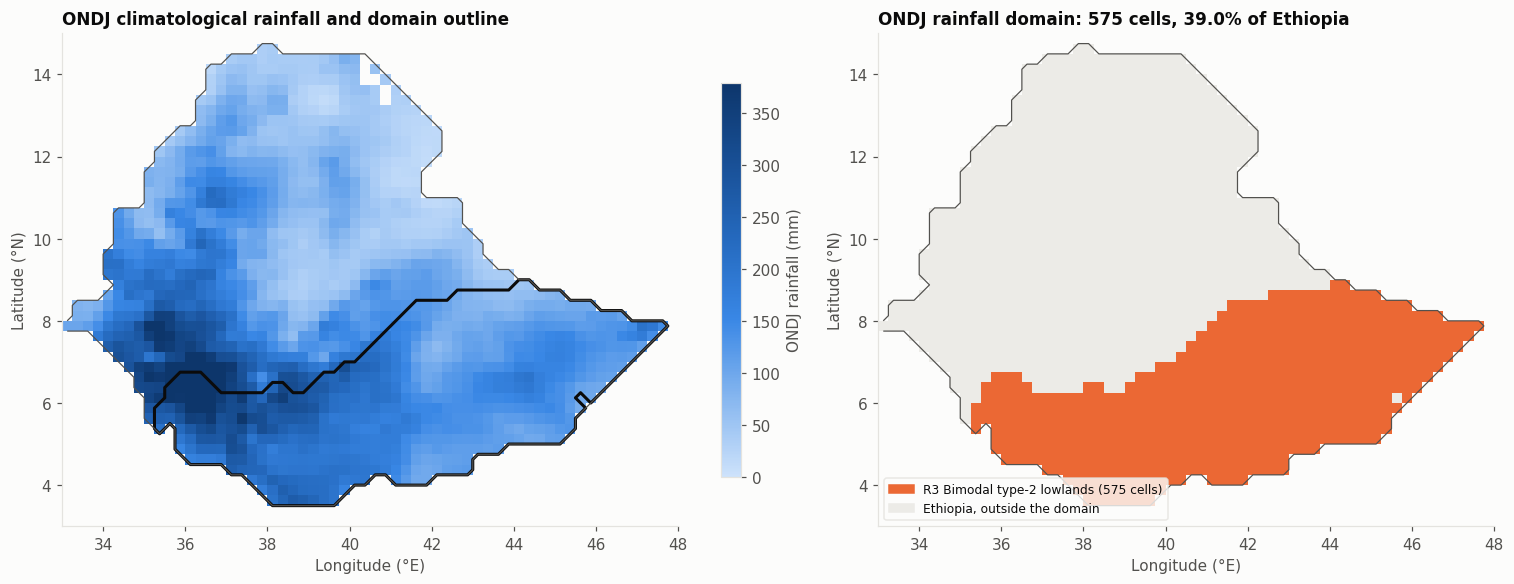

Excluded by the rainfall rule (right regime, too little rain): 0 cells


In [14]:
S = 'ONDJ'; dom = domains[S]; tot = totals[S]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), layout='constrained')
im = axes[0].pcolormesh(lon, lat, np.where(country, tot, np.nan), cmap=SEQ, vmin=0,
                        vmax=float(np.nanpercentile(tot[country], 98)), shading='auto')
fig.colorbar(im, ax=axes[0], shrink=.8, label=f'{S} rainfall (mm)')
axes[0].contour(lon, lat, dom, levels=[.5], colors=[ORANGE if S != 'ONDJ' else INK], linewidths=2)
map_axes(axes[0], f'{S} climatological rainfall and domain outline')
z = np.where(dom, regime, np.nan)
axes[1].pcolormesh(lon, lat, np.where(country, 0, np.nan), cmap=ListedColormap([LAND]), shading='auto')
axes[1].pcolormesh(lon, lat, z, cmap=ListedColormap([REGIME_COLORS[g] for g in range(4)]), vmin=-.5, vmax=3.5, shading='auto')
pct, n = area_share(dom)
map_axes(axes[1], f'{S} rainfall domain: {n} cells, {pct:.1f}% of Ethiopia')
present = [g for g in range(4) if (dom & (regime == g)).any()]
axes[1].legend(handles=[Patch(color=REGIME_COLORS[g], label=f'{REGIME_NAMES[g]} ({int((dom & (regime == g)).sum())} cells)') for g in present]
               + [Patch(color=LAND, label='Ethiopia, outside the domain')], loc='lower left', fontsize=8,
               facecolor=SURFACE, edgecolor=GRID)
plt.show()
print('Excluded by the rainfall rule (right regime, too little rain):',
      int((np.isin(regime, SEASONS[S]['regimes']) & country & ~dom).sum()), 'cells')

**Reading it.** The Deyr / Hagaya domain is the southern and south-eastern pastoral lowlands (Somali Region, Borana,
Guji, South Omo), where October–November rains are the second rainy season, strongly linked to the Indian Ocean Dipole
and ENSO. January adds little rain, so the ONDJ and OND domains are almost the same.

In [15]:
prev = xr.open_dataset('data/masks/init09_ONDJ_rainfall_domain.nc').season_domain.values == 1
ond = remove_small(np.isin(regime, [3]) & (season_total([10, 11, 12]) >= 30) & country, 3)
comp = pd.DataFrame([
    dict(definition='Walkthrough logic, ONDJ (R3, ≥ 30 mm)', cells=int(domains['ONDJ'].sum()), area_pct=area_share(domains['ONDJ'])[0]),
    dict(definition='Walkthrough logic, OND only (R3, ≥ 30 mm)', cells=int(ond.sum()), area_pct=area_share(ond)[0]),
    dict(definition='Earlier ONDJ domain (≥ 120 mm and ≥ 20 % of annual, any regime)', cells=int(prev.sum()), area_pct=area_share(prev)[0]),
]).set_index('definition')
display(comp)
both = domains['ONDJ'] & prev
print(f'Overlap with the earlier ONDJ domain: {int(both.sum())} cells; only in the regime-based domain: '
      f'{int((domains["ONDJ"] & ~prev).sum())}; only in the earlier domain: {int((prev & ~domains["ONDJ"]).sum())}')

,cells,area_pct
definition,,
"Walkthrough logic, ONDJ (R3, ≥ 30 mm)",575,39.00
"Walkthrough logic, OND only (R3, ≥ 30 mm)",575,39.00
"Earlier ONDJ domain (≥ 120 mm and ≥ 20 % of annual, any regime)",487,33.04


Overlap with the earlier ONDJ domain: 434 cells; only in the regime-based domain: 141; only in the earlier domain: 53


**Two ways to define an ONDJ domain.** The earlier domain used for the ONDJ forecast maps (`build_season_domain.py`)
applies the JJAS *rainfall* criteria (≥ 120 mm and ≥ 20 % of annual) to ONDJ in every regime. The walkthrough logic used
here instead starts from the **regime** (R3, the true Gu–Deyr bimodal lowlands) with a low rainfall floor (30 mm), so it
also includes the drier eastern lowlands where Deyr is still the second rainy season, and it leaves out wet highland
cells whose October rain is the tail of Kiremt. Which one to use for products is a choice to make explicitly.

<a id="s11"></a>
## 11. The three domains together

Each cell can belong to more than one seasonal domain: a highland R2 cell is in both the Belg (FMAM) and Kiremt (JJAS)
domains. R3 lowland cells are in the ONDJ domain only, and R1 western cells in JJAS only.

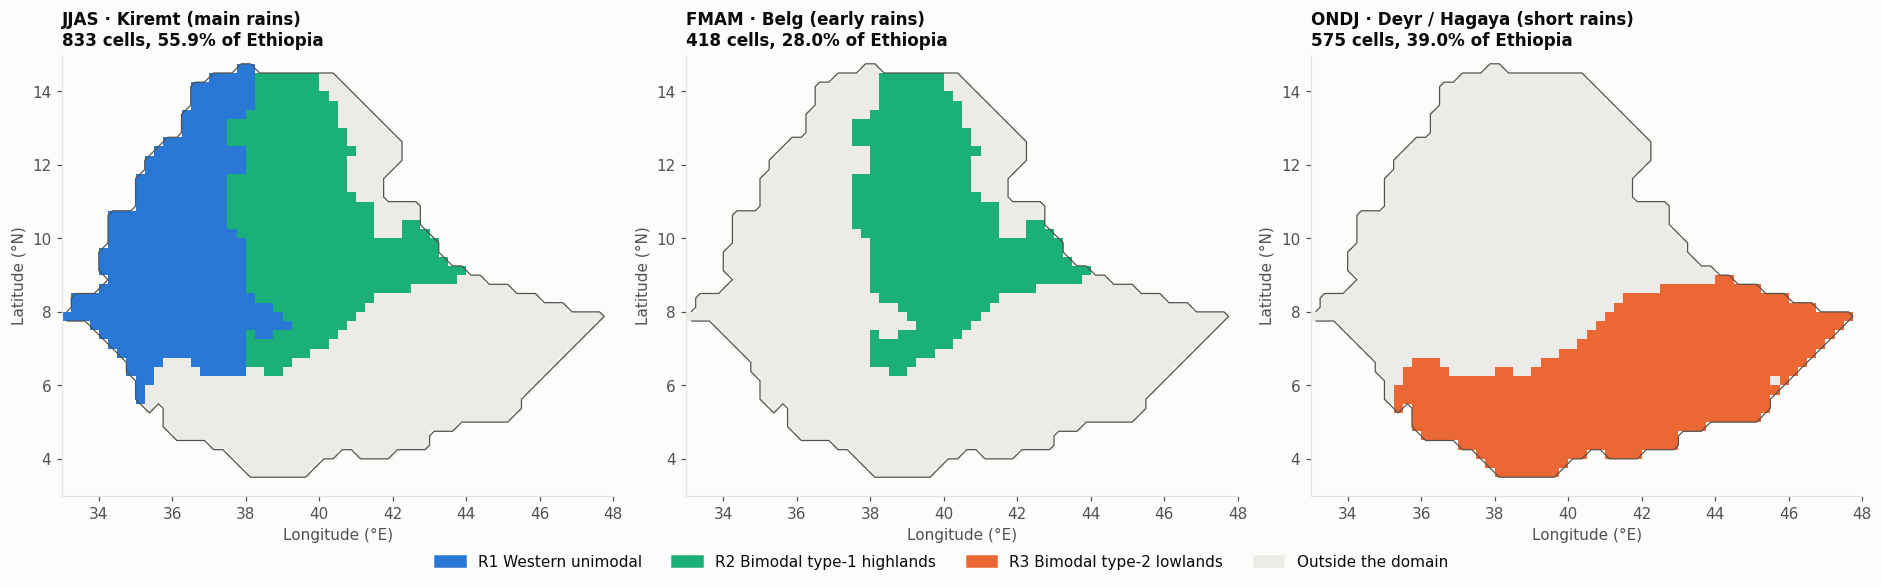

,cells
ONDJ,575
"JJAS,FMAM",418
JJAS,415
none,76


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), layout='constrained')
for ax, (S, rule) in zip(axes, SEASONS.items()):
    ax.pcolormesh(lon, lat, np.where(country, 0, np.nan), cmap=ListedColormap([LAND]), shading='auto')
    ax.pcolormesh(lon, lat, np.where(domains[S], regime, np.nan), cmap=ListedColormap([REGIME_COLORS[g] for g in range(4)]),
                  vmin=-.5, vmax=3.5, shading='auto')
    pct, n = area_share(domains[S]); map_axes(ax, f'{S} · {rule["name"]}\n{n} cells, {pct:.1f}% of Ethiopia')
fig.legend(handles=[Patch(color=REGIME_COLORS[g], label=REGIME_NAMES[g]) for g in [1, 2, 3]] + [Patch(color=LAND, label='Outside the domain')],
           loc='lower center', ncol=4, frameon=False, bbox_to_anchor=(.5, -.06))
plt.show()

combo = pd.Series([','.join(s for s in SEASONS if domains[s][i, j]) or 'none' for i, j in zip(*np.nonzero(country))]).value_counts()
display(combo.rename('cells').to_frame())

<a id="s12"></a>
## 12. Saving the masks

The regimes and the three domains are written to one NetCDF file on the project's common 0.25° grid, so they can be
used as presentation layers (like `build_season_domain.py` masks) or exported to GIS.

In [17]:
out = Path('outputs/regime_domains'); out.mkdir(parents=True, exist_ok=True)
ds = xr.Dataset({'regime': (('lat', 'lon'), regime.astype('int8')), 'region_mask': (('lat', 'lon'), country.astype('int8')),
                 'harmonic_ratio': (('lat', 'lon'), F['harmonic_ratio']), 'annual_mm': (('lat', 'lon'), annual)},
                coords={'lat': lat, 'lon': lon})
for S, rule in SEASONS.items():
    ds[f'domain_{S}'] = (('lat', 'lon'), domains[S].astype('int8'))
    ds[f'domain_{S}'].attrs.update(regimes=json.dumps(rule['regimes']), min_mm=rule['min_mm'],
                                   min_share=-1 if rule['min_share'] is None else rule['min_share'], months=json.dumps(rule['months']))
    ds[f'{S}_climatology_mm'] = (('lat', 'lon'), totals[S])
ds.regime.attrs['codes'] = json.dumps(LABELS)
ds.attrs.update(method=METHOD, source=SOURCE_URL, walkthrough='https://github.com/YonSci/-Operational-Multi-Model-Seasonal-Forecasting-System/blob/main/docs/scientific_masking/WALKTHROUGH.md', climatology='CHIRPS v2.0 1993-2025, 365-day cycle',
                cleanup='patches < 3 cells removed (4-connected)', onset_detection_filter='not applied')
path = out / 'seasonal_regime_domains.nc'; ds.to_netcdf(path)
print('Saved', path, '|', ', '.join(f'domain_{s}' for s in SEASONS))

Saved outputs\regime_domains\seasonal_regime_domains.nc | domain_JJAS, domain_FMAM, domain_ONDJ


<a id="s13"></a>
## 13. Exporting shapefiles and GeoJSON

The masks are grids of 0.25° cells. For GIS use (QGIS, ArcGIS, GeoPandas, R `sf`) each mask is turned into polygons:
every selected cell becomes a 0.25° × 0.25° square, adjacent squares are merged (dissolved) into one outline, and the
result is written as an **ESRI shapefile** (`.shp`, `.shx`, `.dbf`, `.prj`) and as **GeoJSON**, in **WGS 84
(EPSG:4326)**.

| Layer | Features |
| --- | --- |
| `ethiopia_four_climate_regimes` | one (multi)polygon per regime R0–R3 |
| `mask_kiremt_jjas` | JJAS domain (R1 + R2) |
| `mask_belg_fmam` | FMAM domain (R2) |
| `mask_deyr_ondj` | ONDJ domain (R3) |

Attribute fields follow the walkthrough's schema: `regime_id`, `regime_nam`, `season_typ`, `pixel_cnt`, `area_pct`,
`desc`. The domain layers carry one feature per contributing regime, so the JJAS layer can still be coloured R1 / R2.

In [18]:
import shapefile, zipfile
from shapely.geometry import box, mapping, shape as to_shape
from shapely.geometry.polygon import orient
from shapely.ops import unary_union

HALF = 0.125   # half a 0.25° cell
WGS84 = ('GEOGCS["GCS_WGS_1984",DATUM["D_WGS_1984",SPHEROID["WGS_1984",6378137.0,298.257223563]],'
         'PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]]')

def cells_to_polygon(mask):
    # Dissolve the selected grid cells into (multi)polygons with exact cell edges.
    squares = [box(lon[j] - HALF, lat[i] - HALF, lon[j] + HALF, lat[i] + HALF) for i, j in zip(*np.nonzero(mask))]
    geom = unary_union(squares)
    parts = list(geom.geoms) if geom.geom_type == 'MultiPolygon' else [geom]
    return [orient(g, sign=-1.0) for g in parts]          # ESRI: clockwise outer rings, counter-clockwise holes

DESC = {0: 'Non-seasonal arid climate (annual < 200 mm); seasonal metrics masked',
        1: 'Single long wet season Mar-Oct peaking Jul-Aug; Atlantic/Congo westerlies',
        2: 'Belg (FMAM) and Kiremt (JJAS) separated by a June dry break',
        3: 'Gu (MAM) and Deyr/Hagaya (OND) separated by a dry summer; Indian Ocean'}

def write_layer(name, features):
    # features: list of (attributes dict, mask). Writes .shp/.shx/.dbf/.prj and .geojson.
    shp_dir.mkdir(parents=True, exist_ok=True)
    w = shapefile.Writer(str(shp_dir / name), shapeType=shapefile.POLYGON)
    for field, kind, size, dec in [('regime_id', 'N', 10, 0), ('regime_nam', 'C', 100, 0), ('season_typ', 'C', 100, 0),
                                   ('pixel_cnt', 'N', 10, 0), ('area_pct', 'N', 12, 3), ('desc', 'C', 254, 0)]:
        w.field(field, kind, size=size, decimal=dec)
    geo = {'type': 'FeatureCollection', 'name': name, 'features': []}
    for attrs, mask in features:
        parts = cells_to_polygon(mask)
        rings = []
        for poly in parts:
            rings.append([list(c) for c in poly.exterior.coords])
            rings.extend([list(c) for c in hole.coords] for hole in poly.interiors)
        w.poly(rings)
        pct, n = area_share(mask)
        row = dict(attrs, pixel_cnt=n, area_pct=round(pct, 3))
        w.record(row['regime_id'], row['regime_nam'], row['season_typ'], n, row['area_pct'], row['desc'])
        geo['features'].append({'type': 'Feature', 'properties': row,
                                'geometry': mapping(unary_union(parts))})
    w.close()
    (shp_dir / f'{name}.prj').write_text(WGS84)
    (shp_dir / f'{name}.geojson').write_text(json.dumps(geo))
    return name

shp_dir = Path('outputs/regime_domains/shapefiles')
layers = []
layers.append(write_layer('ethiopia_four_climate_regimes',
    [(dict(regime_id=g, regime_nam=REGIME_NAMES[g], season_typ='annual regime', desc=DESC[g]), regime == g) for g in range(4)]))
DOMAIN_LAYERS = {'JJAS': ('mask_kiremt_jjas', 'JJAS'), 'FMAM': ('mask_belg_fmam', 'FMAM'), 'ONDJ': ('mask_deyr_ondj', 'ONDJ')}
for S, (layer, season_type) in DOMAIN_LAYERS.items():
    rule = SEASONS[S]
    layers.append(write_layer(layer, [
        (dict(regime_id=g, regime_nam=f'{rule["name"]} domain: {REGIME_NAMES[g]}', season_typ=season_type,
              desc=f'{S} domain cells in R{g}; rule ' + summary.loc[S, 'rule']), domains[S] & (regime == g))
        for g in rule['regimes']]))

archive = shp_dir.parent / 'ethiopia_rainfall_regimes_and_domains_shp.zip'
with zipfile.ZipFile(archive, 'w', zipfile.ZIP_DEFLATED) as z:
    for f in sorted(shp_dir.iterdir()):
        z.write(f, f.name)
files = pd.DataFrame([dict(file=f.name, kB=round(f.stat().st_size / 1e3, 1)) for f in sorted(shp_dir.iterdir())])
display(files.set_index('file'))
import shutil
tracked = Path('data/masks') / archive.name           # tracked in git, so the shapefiles are also on GitHub
shutil.copy2(archive, tracked)
print('Zip archive:', archive, f'({archive.stat().st_size / 1e3:.1f} kB); copy for the repository:', tracked)

,kB
file,
ethiopia_four_climate_regimes.dbf,2.2
ethiopia_four_climate_regimes.geojson,8.9
ethiopia_four_climate_regimes.prj,0.1
ethiopia_four_climate_regimes.shp,8.8
ethiopia_four_climate_regimes.shx,0.1
mask_belg_fmam.dbf,0.7
mask_belg_fmam.geojson,2.4
mask_belg_fmam.prj,0.1
mask_belg_fmam.shp,2.4


Zip archive: outputs\regime_domains\ethiopia_rainfall_regimes_and_domains_shp.zip (10.7 kB); copy for the repository: data\masks\ethiopia_rainfall_regimes_and_domains_shp.zip


**Check.** The files are read back from disk with `pyshp`. Each 0.25° cell covers 0.0625 square degrees, so a
polygon's area divided by 0.0625 must equal its `pixel_cnt` exactly — this confirms that no cell was lost or added when
the cells were dissolved into outlines.

In [19]:
rows = []
for name in layers:
    with shapefile.Reader(str(shp_dir / name)) as r:
        fields = [f[0] for f in r.fields[1:]]
        for sr in r.iterShapeRecords():
            rec = dict(zip(fields, sr.record)); geom = to_shape(sr.shape.__geo_interface__)
            rows.append(dict(layer=name, regime_id=rec['regime_id'], pixel_cnt=rec['pixel_cnt'], area_pct=rec['area_pct'],
                             polygons=len(geom.geoms) if geom.geom_type == 'MultiPolygon' else 1,
                             cells_from_area=round(geom.area / 0.0625, 6)))
check_shp = pd.DataFrame(rows)
check_shp['matches'] = check_shp.cells_from_area == check_shp.pixel_cnt
display(check_shp)
print('All polygon areas equal their cell counts:', check_shp.matches.all())
valid = []
for name in layers:
    with shapefile.Reader(str(shp_dir / name)) as r:
        valid += [to_shape(sh.__geo_interface__).is_valid for sh in r.shapes()]
    json.loads((shp_dir / f'{name}.geojson').read_text())
print('All geometries valid (no self-intersections):', all(valid), '| GeoJSON files parse:', True)

,layer,regime_id,pixel_cnt,area_pct,polygons,cells_from_area,matches
0,ethiopia_four_climate_regimes,0,64,4.27,1,64.0,True
1,ethiopia_four_climate_regimes,1,421,28.30,6,421.0,True
2,ethiopia_four_climate_regimes,2,418,28.04,1,418.0,True
3,ethiopia_four_climate_regimes,3,575,39.00,1,575.0,True
4,mask_kiremt_jjas,1,415,27.90,1,415.0,True
5,mask_kiremt_jjas,2,418,28.04,1,418.0,True
6,mask_belg_fmam,2,418,28.04,1,418.0,True
7,mask_deyr_ondj,3,575,39.00,1,575.0,True


All polygon areas equal their cell counts: True
All geometries valid (no self-intersections): True | GeoJSON files parse: True


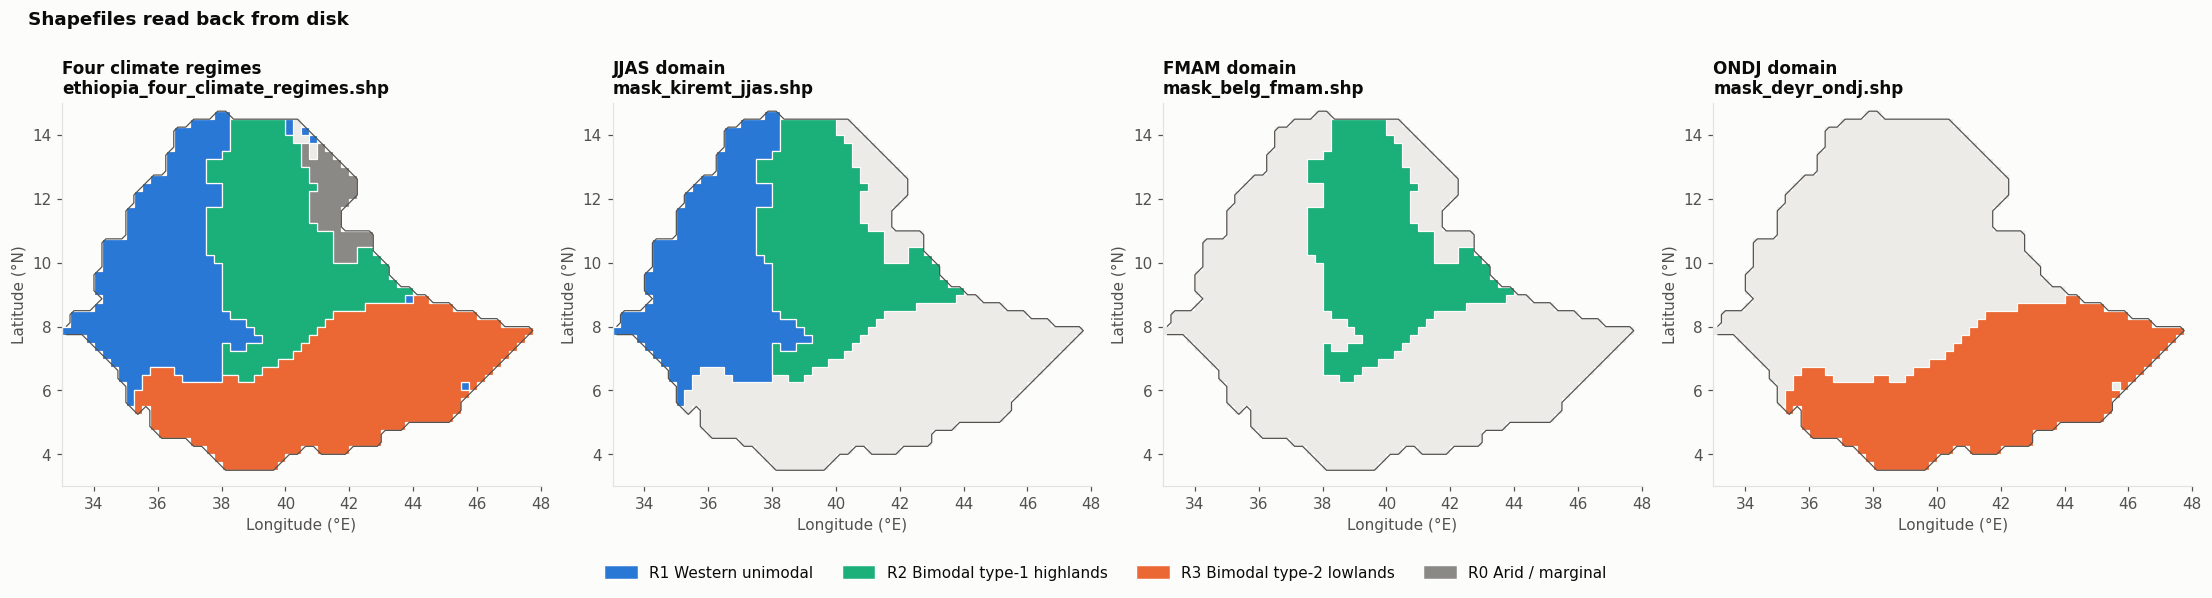

In [20]:
from matplotlib.patches import PathPatch
from matplotlib.path import Path as MPath

def draw(ax, layer, colour_of):
    with shapefile.Reader(str(shp_dir / layer)) as r:
        for sr in r.iterShapeRecords():
            geom = to_shape(sr.shape.__geo_interface__)
            for poly in (geom.geoms if geom.geom_type == 'MultiPolygon' else [geom]):
                verts, codes = [], []
                for ring in [poly.exterior, *poly.interiors]:
                    xy = list(ring.coords); verts += xy; codes += [MPath.MOVETO] + [MPath.LINETO] * (len(xy) - 2) + [MPath.CLOSEPOLY]
                ax.add_patch(PathPatch(MPath(verts, codes), facecolor=colour_of(sr.record), edgecolor=SURFACE, linewidth=.8))

fig, axes = plt.subplots(1, 4, figsize=(20, 5), layout='constrained')
titles = ['Four climate regimes'] + [f'{S} domain' for S in DOMAIN_LAYERS]
for ax, layer, title in zip(axes, layers, titles):
    ax.pcolormesh(lon, lat, np.where(country, 0, np.nan), cmap=ListedColormap([LAND]), shading='auto')
    draw(ax, layer, lambda rec: REGIME_COLORS[int(rec[0])])
    map_axes(ax, f'{title}\n{layer}.shp'); ax.set_xlim(33, 48); ax.set_ylim(3, 15)
fig.legend(handles=[Patch(color=REGIME_COLORS[g], label=REGIME_NAMES[g]) for g in [1, 2, 3, 0]], loc='lower center', ncol=4,
           frameon=False, bbox_to_anchor=(.5, -.07))
fig.suptitle('Shapefiles read back from disk', x=.01, ha='left', fontweight='bold'); plt.show()

**Using the files.** In QGIS: *Layer → Add Vector Layer* and pick a `.shp` or `.geojson`. In Python:
`geopandas.read_file('outputs/regime_domains/shapefiles/mask_kiremt_jjas.shp')`. In R:
`sf::st_read(...)`. The outlines follow the 0.25° CHIRPS grid cells exactly; they are not smoothed.

<a id="s14"></a>
## 14. Caveats

* **Not an official EMI zoning.** The regimes are an objective, reproducible classification following the walkthrough;
  they are not certified EMI climate zones.
* **No onset filter.** The walkthrough's detection-rate filter (DR ≥ 50–60 %) needs onset diagnostics and is not applied.
* **Climatology period.** 1993–2025 CHIRPS. A different period (for example WMO 1991–2020) can move cells near
  thresholds between regimes.
* **ONDJ vs OND.** The walkthrough defines Deyr on OND; extending to January adds little rain but is a choice.
* **0.25° cells near borders** (for example around Moyale) can be affected by the country mask and cleanup.

<a id="s15"></a>
## 15. Exercises

1. Change the JJAS share threshold from 20 % to 25 %. Which cells leave the domain, and in which regime?
2. Define a **MAM Gu** domain for regime R3 (the walkthrough's `mask_gu_spring_rains`). How large is it?
3. Replace ONDJ by ONDJF (add February) in `SEASONS`. Does the domain change?
4. Find a station in the table of section 6 with r_H < 1 that is still classified as bimodal (R2). Which rule promoted it?
5. Compare the ONDJ domain here with the one used for the ONDJ 2026/27 forecast maps (section 10). Which would you
   recommend for the September outlook, and why?

<a id="s16"></a>
## 16. References

* Dunning, C. M., Black, E. C. L. and Allan, R. P. (2016). The onset and cessation of seasonal rainfall over Africa.
  *J. Geophys. Res. Atmos.* 121, 11405–11424.
* Funk, C. et al. (2015). The climate hazards infrared precipitation with stations (CHIRPS). *Sci. Data* 2, 150066.
* Scientific masking walkthrough: [https://github.com/YonSci/-Operational-Multi-Model-Seasonal-Forecasting-System/blob/main/docs/scientific_masking/WALKTHROUGH.md](https://github.com/YonSci/-Operational-Multi-Model-Seasonal-Forecasting-System/blob/main/docs/scientific_masking/WALKTHROUGH.md)
* Project code: `scripts/github_regime_core.py`, `scripts/prepare_regimes.py`, `scripts/build_season_domain.py`;
  docs 25–26 (regimes), 34 (R1+R2 presentation layer), 38 (runbook).

*Generated by `notebooks/build_rainfall_domains_notebook.py`.*